# Building a neural network from scratch with NumPy
This notebook documents the full process of implementing a basic feedforward neural network to classify handwritten digits using the MNIST dataset.

## 1. Introduction
### Why build from scratch?
Modern machine learning frameworks like PyTorch and Tensorflow are incredibly powerful - but they abstract away almost all of the core mathematical operations. While this is ideal for productivity, since neural networks can be built in a few lines of code, it can lead to a shallow understanding of what's actually happening under the hood.

I find I need to take complex ideas apart into their smallest building blocks and rebuild them myself before I truly understand why they work, and can confidently apply that knowledge to new problems. This project is that process: my attempt to lift the hood on neural networks by implementing one from scratch using only NumPy. The goal is simple: if I can't build it myself, then I don't fully understand it.

### Why this format?
Jupyter notebooks allow me to weave together markdown, LaTeX and Python into a singular narrative. This flexibility turns the project into more than just code - it becomes a computational notebook in the truest sense:
- Markdown captures the reasoning and context
- LaTeX allows accurate typesetting of complex mathematical expressions
- Python turns theory into executable code.

This particular format encourages deep thinking and makes the learning process visible - not just the end result. It also aligns with the traditions of science and mathematics, where understanding is often built through annotated derivations, not just final answers. 

### Overview of Architecture
The most basic versions of neural networks are known as multi-layer perceptrons, or MLPs. 

We will build a MLP with a single hidden layer

In [ ]:
$$ z= w_1 x_1+w_2 x_2+w_n x_n =\textbf{X}^T \textbf{W} $$

## 2. Load and Preprocess MNIST dataset
Yes, I know this comes from Keras, but honestly, this was the fastest way to get the data as a numpy array. The original data is in some obscure binary format. Each image is a 28x28 numpy array. 
**Training set:** contains 60,000 images. 
**Test set:** contains 10,000 images.

Firstly, we need to normalise the dataset. Currently, the arrays for the images are between 0 (completely black pixel) and 255 (completely white pixel). However, neural networks really, _really_ like inputs to be between 0 and 1. Easiest way to do this: simply divide every value in the array by 255. 

Next, squash the array for each image to a 1-dimensional vector. These 1D vectors are much faster to calculate than a 28x28 matrix. This will give a 1D vector of 784 columns (28x28 = 784) for each image. The training set should then be an array of 60000 rows and 784 columns, and the  test set 1000 rows and also 784 columns. The labels are already a 1D array and do not need reshaping here. 

Finally, One-hot encode the labels, and convert them from ["6, 9, 4, 3"] to strings of ones and zeros representing the number. **Remember** Python indexes from zero, not one. So the array is 0-9, not 1-9, and then 0. 

Array: [[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253

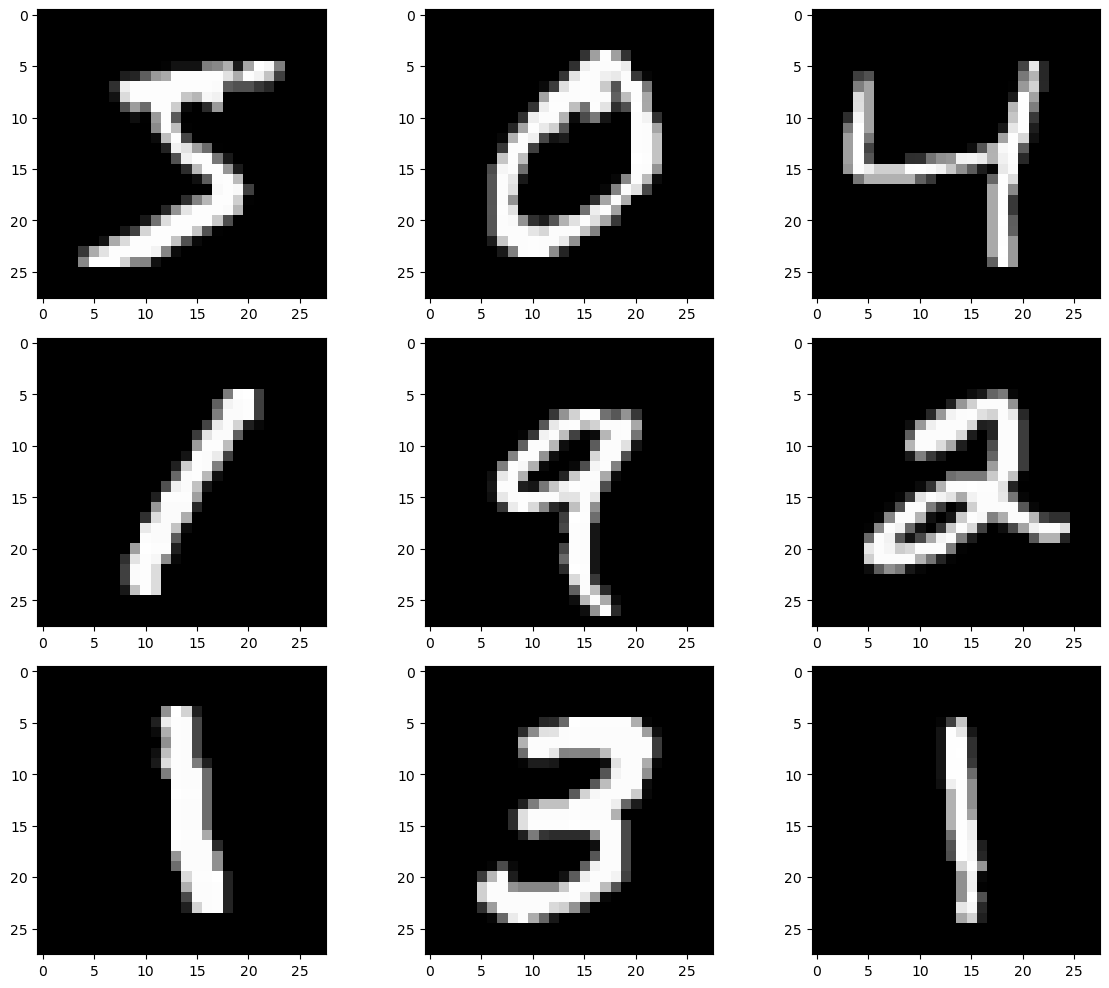

In [15]:
# Import necessary packages
import numpy as np 
import pandas as pd
from keras.datasets import mnist
import matplotlib.pyplot as plt 

# Import and visualise the data
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print(f'Array: {X_train[0]}')
print(f'Training Label: {y_train[0]}')

#Plot the first 9 images in the data set
fig, ax = plt.subplots(3,3) 
fig.set_size_inches(12, 10)
k = 0
for i in range(3):
    for j in range(3):
        ax[i,j].imshow(X_train[k].reshape(28, 28), cmap="gray")
        k += 1
plt.tight_layout()


In [ ]:
# Normalise the data
X_train = X_train/255
X_test = X_test/255

#print(f'Normalised Array: {X_train[0]}')
# Flatten X_train and X_test to 1 dimension, then confirm we have done so using .shape method
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_test: {X_test.shape}')

# One Hot encode the image labels
# Code shamelessly borrows from: https://stackoverflow.com/questions/29831489/convert-array-of-indices-to-one-hot-encoded-array-in-numpy

n_values = np.max(y_train) + 1
y_train_encoded = np.eye(n_values)[y_train]
n_values = np.max(y_test) + 1
y_test_encoded = np.eye(n_values)[y_test]

# Select a random image from the training and test set and print the original label and encoded label to confirm this has worked. 
print(f'Original label: {y_train[42]}\nEncoded label: {y_train_encoded[42]}')
print(f'Original label: {y_test[42]}\nEncoded label: {y_test_encoded[42]}')

Shape of X_train: (60000, 784)
Shape of X_test: (10000, 784)
Original label: 7
Encoded label: [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
Original label: 4
Encoded label: [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]


## 3. Define Core Components of the Neural Network
- dense (fully connected) layer
- activation functions (reLU, Sigmoid, Softmax)
- Loss function (cross-entropy)
- optimisation (Adam, SDG)
- Accuracy metric

## 4. Forward Propagation
- show data moving through layers
- visualise activations


## 5. Backward Propagation
- chain rule underpins back prop
- compute gradients manually
- show how weights update

## 6. Training Loop
- Track accuracy, loss
- plot learning curve

## 7. Evaluation
- Test set accuracy
- confusion matrix

## 8. Wrap Up
- Refactor code to modules
- Comparison with Pytorch